In [1]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd
import seaborn as sns

In [2]:
#Note this is data with hurricane helene outages removed
outage_events = pd.read_csv('data_processed/PCA_data/outage_events.csv')

outage_events.dtypes

outage_identifer           int64
device_lat               float64
device_lon               float64
block_fips               float64
convex_hull               object
jurisdiction              object
origin                    object
state                     object
county                    object
affected                   int64
cause                     object
outage_start_estimate     object
outage_end_estimate       object
fix_duration_estimate     object
outage_restored           object
fix_duration_hours       float64
TRACT                      int64
overlaps_helene             bool
countyfp                   int64
is_western_nc               bool
drop_for_helene             bool
customer_minutes_out     float64
month                      int64
is_summer                   bool
is_winter                   bool
nearest_station           object
start_date                object
end_date                  object
outage_dates              object
dtype: object

In [3]:
basic_stats = outage_events[[
    "fix_duration_hours",
    "customer_minutes_out",
    "affected"
]].describe().T

basic_stats

,count,mean,std,min,25%,50%,75%,max
fix_duration_hours,357191.0,3.600289,10.025199,0.090556,0.363333,1.497500,3.176667,6.999989e+02
customer_minutes_out,357191.0,6290.521862,149056.349849,5.433333,32.091667,128.816667,381.500000,2.635334e+07
affected,357315.0,21.599040,143.800199,1.000000,1.000000,1.000000,2.000000,6.784000e+03


In [7]:
# Total number of rows
total = len(outage_events)

# Percentage of outages in summer
pct_summer = outage_events["is_summer"].sum() / total

# Percentage of outages in winter
pct_winter = outage_events["is_winter"].sum() / total

#Percentage of outages that are unplanned
pct_unplanned = (outage_events["cause"] == "unplanned").sum() / total

print("pct_summer:" + str(pct_summer))
print("pct_winter:" + str(pct_winter))
print("pct_unplanned:" + str(pct_unplanned))


pct_summer:0.43552327778010996
pct_winter:0.134657095280075
pct_unplanned:0.8726725718203826


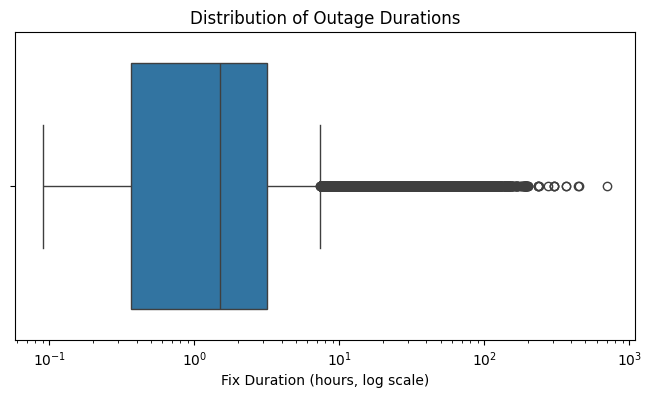

In [4]:
plt.figure(figsize=(8,4))
sns.boxplot(x=outage_events["fix_duration_hours"])
plt.xscale("log")   # recommended due to heavy tail
plt.xlabel("Fix Duration (hours, log scale)")
plt.title("Distribution of Outage Durations")
plt.show()

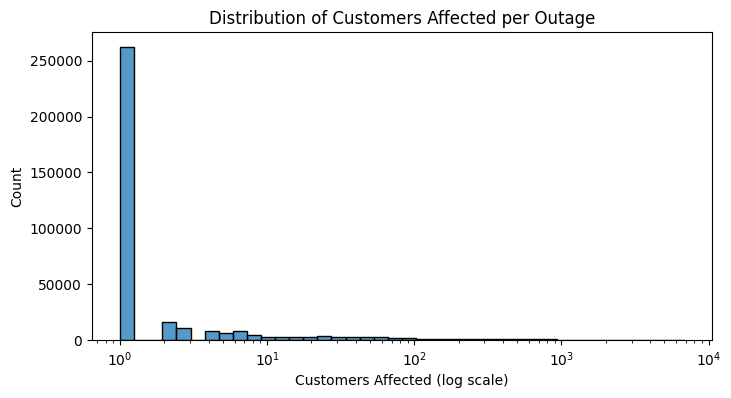

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(outage_events["affected"], bins=40, log_scale=True)
plt.xlabel("Customers Affected (log scale)")
plt.title("Distribution of Customers Affected per Outage")
plt.show()

In [6]:
# identify numeric columns automatically (excluding things like lon/lat if desired)
numeric_cols = outage_events.select_dtypes(include=[np.number]).columns.tolist()

#remove columns that don’t make sense as “extremes”
remove = ['device_lat',
          'device_lon',
          'TRACT',
          'outage_identifer', 
          'block_fips', 
          'convex_hull', 
          'jurisdiction',
          'origin',
          'state',
          'county',
          'cause',
          'outage_start_estimate',
          'outage_end_estimate',
          'outage_restored',
          'overlaps_helene',
          'month',
          'is_summer',
          'is_winter',
          'nearest_station',
          'start_date',
          'end_date',
          'outage_dates']

numeric_cols = [c for c in numeric_cols if c not in remove]

print("Using numeric columns:", numeric_cols)

# compute z-scores for each numeric column
zdf = outage_events.copy()
for col in numeric_cols:
    zdf[col + "_z"] = (outage_events[col] - outage_events[col].mean()) / outage_events[col].std(ddof=0)

# flag where |z| exceeds threshold (extreme)
threshold = 2
for col in numeric_cols:
    zdf[col + "_is_extreme"] = zdf[col + "_z"].abs() > threshold

# count extremes per TRACT
extreme_cols = [c for c in zdf.columns if c.endswith("_is_extreme")]
tract_extreme_counts = zdf.groupby("TRACT")[extreme_cols].sum()

# total across all cols
tract_extreme_counts["extreme_total"] = tract_extreme_counts.sum(axis=1)

# sort to get the tract with the most extreme values
top_extreme = tract_extreme_counts.sort_values("extreme_total", ascending=False)

print("Top TRACT with most extreme values:")
print(top_extreme.head(10))

top_extreme.to_csv("data_processed/outage_summary.csv", index= True)


Using numeric columns: ['affected', 'fix_duration_hours', 'countyfp', 'customer_minutes_out']
Top TRACT with most extreme values:
             affected_is_extreme  fix_duration_hours_is_extreme  \
TRACT                                                             
37121950400                   12                            181   
37121950300                   13                            172   
37111970800                    6                            120   
37021003003                    5                            106   
37089930100                    8                            106   
37021003204                   18                             85   
37021002704                    4                            108   
37021003002                   12                             89   
37021003203                    0                             91   
37011930400                    5                             77   

             countyfp_is_extreme  customer_minutes_out_is_extreme

In [7]:
from pathlib import Path

gdf_path = Path("data_processed/socioeconomic_tracts_with_pca_and_clusters.geojson")
outages_path = Path("data_raw/outages.csv")   # change if your outages CSV is elsewhere

gdf = gpd.read_file(gdf_path)
#gdf['TRACT'] = gdf.get('TRACT', gdf.get('GEOID', '')).astype(str).str.zfill(6)

df = outage_events
if 'TRACT' not in df.columns:
    if 'GEOID' in df.columns:
        df['TRACT'] = df['GEOID'].astype(str).str[-6:]
    elif 'tract' in df.columns:
        df['TRACT'] = df['tract']
#df['TRACT'] = df['TRACT'].astype(str).str.zfill(6)

# choose numeric columns (exclude lat/lon/ids)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['device_lat','device_lon','lat','lon','longitude','latitude','TRACT','outage_identifier']
numeric_cols = [c for c in numeric_cols if c not in exclude]

# compute z-scores and flags
zdf = df.copy()
for c in numeric_cols:
    std = df[c].std(ddof=0)
    zdf[c + "_z"] = 0.0 if (std == 0 or pd.isna(std)) else (df[c] - df[c].mean()) / std
    zdf[c + "_is_extreme"] = zdf[c + "_z"].abs() > 2

extreme_flags = [c for c in zdf.columns if c.endswith("_is_extreme")]
tract_counts = zdf.groupby("TRACT")[extreme_flags].sum().astype(int)
tract_counts['extreme_total'] = tract_counts.sum(axis=1)
zcols = [c for c in zdf.columns if c.endswith("_z")]
tract_max_abs_z = zdf.assign(max_abs_z=zdf[zcols].abs().max(axis=1)).groupby("TRACT")['max_abs_z'].max()
tract_stats = tract_counts.merge(tract_max_abs_z, left_index=True, right_index=True)
tract_stats = tract_stats.reset_index().sort_values(['extreme_total','max_abs_z'], ascending=[False, False])
top5 = tract_stats.head(5)
print("Top 5 tracts:", top5[['TRACT','extreme_total','max_abs_z']])

# plot
plot_gdf = gdf.copy()
plot_gdf['is_top5'] = plot_gdf['TRACT'].isin(top5['TRACT'].astype(str).tolist())
top5_gdf = plot_gdf[plot_gdf['is_top5']].copy()

fig, ax = plt.subplots(1,1, figsize=(8,8))
plot_gdf.plot(ax=ax, color="#EEEEEE", edgecolor="#BBBBBB", linewidth=0.25)

if len(top5_gdf):
    top5_gdf.plot(
        ax=ax,
        facecolor='#ff9999',
        edgecolor='#cc0000',
        linewidth=0.9,
        alpha=0.9
    )

    # LABEL ONLY THE TRACT ID (no extreme score)
    for _, row in top5_gdf.iterrows():
        rep = row.geometry.representative_point()
        tract = row['TRACT']
        ax.text(
            rep.x,
            rep.y,
            tract,   # <-- only showing TRACT
            fontsize=8,
            ha='center',
            va='center',
            color='black',
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7)
        )

ax.set_axis_off()
plt.title("Top 5 Tracts by Extreme Metrics")
out_png = "top5_extreme_tracts.png"
plt.savefig(out_png, bbox_inches='tight', pad_inches=0.1)
print("Saved:", out_png)


DataSourceError: data_processed/socioeconomic_tracts_with_pca_and_clusters.geojson: No such file or directory

In [8]:
# ensure df is your outage_events dataframe
df = outage_events.copy()

# If block_fips exists but is float-ish like 370670038032008.0 -> convert to string without .0
if 'block_fips' in df.columns:
    # convert to string robustly (handles floats and ints), drop decimal .0 if present
    df['block_fips_str'] = df['block_fips'].astype(str).str.replace(r'\.0+$', '', regex=True)
    # pad to 15 characters if needed (FIPS: 2+3+6+4 = 15)
    df['block_fips_str'] = df['block_fips_str'].str.zfill(15)
else:
    raise KeyError("block_fips column not found in outage_events")

# Optional: derive tract (6-digit) FROM the block_fips (positions 5:11 for 0-based index)
# This yields the 6-digit tract code embedded in the full FIPS
df['TRACT_from_block'] = df['block_fips_str'].str[5:11]  # 6 chars
df['TRACT_from_block'] = df['TRACT_from_block'].astype(str).str.zfill(6)

# sanity check
print("Example block_fips_str:", df['block_fips_str'].iloc[:3].tolist())
print("Derived TRACT_from_block:", df['TRACT_from_block'].iloc[:3].tolist())


Example block_fips_str: ['370690605023024', '370939703002008', '370939702014013']
Derived TRACT_from_block: ['060502', '970300', '970201']


In [9]:
import numpy as np
import pandas as pd

# pick numeric columns for z-scores (EXCLUDE identifiers)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = [
    'device_lat','device_lon','TRACT','outage_identifer','outage_identifier',
    'convex_hull','jurisdiction','origin','state','county','cause',
    'outage_start_estimate','outage_end_estimate','outage_restored',
    'overlaps_helene','month','is_summer','is_winter','nearest_station',
    'start_date','end_date','outage_dates','block_fips'  # exclude numeric block_fips column
]
numeric_cols = [c for c in numeric_cols if c not in exclude]
print("Numeric columns used for z-scores:", numeric_cols)

# compute z-scores and extreme flags on a copy
zdf = df.copy()
for col in numeric_cols:
    std = zdf[col].std(ddof=0)
    if std == 0 or pd.isna(std):
        zdf[col + "_z"] = 0.0
    else:
        zdf[col + "_z"] = (zdf[col] - zdf[col].mean()) / std
    zdf[col + "_is_extreme"] = zdf[col + "_z"].abs() > 2

# list of extreme flags
extreme_flags = [c for c in zdf.columns if c.endswith("_is_extreme")]

# --- AGGREGATE BY BLOCK (unique) ---
block_extreme_counts = zdf.groupby("block_fips_str")[extreme_flags].sum().astype(int)
block_extreme_counts["extreme_total"] = block_extreme_counts.sum(axis=1)
block_extreme_counts = block_extreme_counts.sort_values("extreme_total", ascending=False).reset_index()

print("Top 5 blocks with most extreme flags:")
print(block_extreme_counts.head(5)[["block_fips_str","extreme_total"]])

# --- ROLL-UP: aggregate block-level extremes to TRACT level (if you want tract summaries) ---
# we have df['TRACT_from_block'] derived earlier
# join block_extreme_counts (indexed by block_fips_str) back to a block->tract mapping (if needed)
block_to_tract = df[['block_fips_str','TRACT_from_block']].drop_duplicates().set_index('block_fips_str')
block_extreme_counts = block_extreme_counts.set_index('block_fips_str').join(block_to_tract, how='left')

# now aggregate by tract
tract_extreme_agg = block_extreme_counts.groupby('TRACT_from_block')[extreme_flags + ['extreme_total']].sum()
tract_extreme_agg = tract_extreme_agg.sort_values('extreme_total', ascending=False)
print("Top 5 tracts after aggregating block extremes:")
print(tract_extreme_agg.head(5)[['extreme_total']])


Numeric columns used for z-scores: ['affected', 'fix_duration_hours', 'customer_minutes_out']
Top 5 blocks with most extreme flags:
    block_fips_str  extreme_total
0  370210027044001             41
1  371590502011014             30
2  371719303021005             30
3  370210027051002             27
4  370210030042016             26
Top 5 tracts after aggregating block extremes:
                  extreme_total
TRACT_from_block               
950400                      278
950300                      237
930100                      152
002704                      152
003003                      146


Using outage_events from memory.
Loaded tracts GeoDataFrame with 2624 rows from data_processed/socioeconomic_tracts_with_pca_and_clusters.geojson
Numeric columns used for z-scores: ['affected', 'fix_duration_hours', 'customer_minutes_out', 'month']
Extreme flag columns: ['affected_is_extreme', 'fix_duration_hours_is_extreme', 'customer_minutes_out_is_extreme', 'month_is_extreme']
Top 5 blocks with most extremes (block -> GEOID):
                 extreme_total        GEOID
block_fips_str                             
370210027044001             53  37021002704
371830531093006             38  37183053109
370370201052008             37  37037020105
371719303021005             34  37171930302
370210031053012             33  37021003105
Top 10 GEOIDs by aggregated extreme_total:
         GEOID  extreme_total
0  37121950400            285
1  37121950300            237
2  37089930100            228
3  37111970800            208
4  37021003204            181
5  37021002704            176
6  370

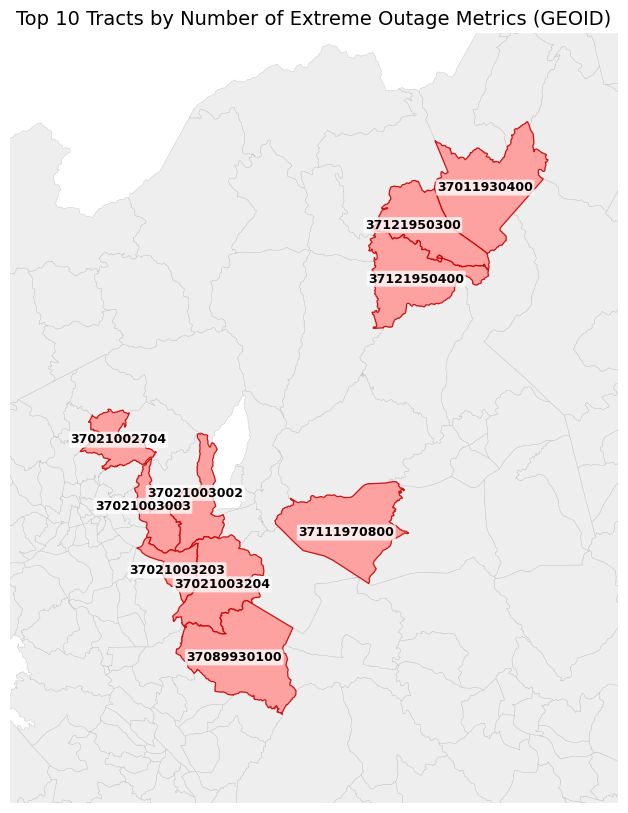

In [10]:
gdf_path = Path("data_processed/socioeconomic_tracts_with_pca_and_clusters.geojson")
output_png = "top_extreme_tracts_map.png"
TOP_N = 10
Z_THRESHOLD = 2.0

# -------------------------
# Load outage events (df)
# -------------------------
try:
    df = outage_events.copy()           # if exists in memory
    print("Using outage_events from memory.")
except NameError:
    # fallback: try reading CSV if variable outages_csv is defined
    try:
        outages_csv  # may raise NameError
        if Path(outages_csv).exists():
            df = pd.read_csv(outages_csv)
            print(f"Loaded outages from {outages_csv}")
        else:
            raise RuntimeError("outages_csv path not found: " + str(outages_csv))
    except NameError:
        raise RuntimeError("No outage_events in memory and outages_csv not defined. Provide data.")

# -------------------------
# Load tracts GeoDataFrame (gdf)
# -------------------------
gdf = gpd.read_file(gdf_path)
print(f"Loaded tracts GeoDataFrame with {len(gdf)} rows from {gdf_path}")

# Normalize gdf GEOID if present (ensure string, 11 digits)
if 'GEOID' in gdf.columns:
    gdf['GEOID'] = gdf['GEOID'].astype(str).str.zfill(11)
else:
    # If gdf doesn't have GEOID but has STATEFP/COUNTYFP/TRACT, build it
    if {'STATEFP','COUNTYFP','TRACT'}.issubset(gdf.columns):
        gdf['GEOID'] = (
            gdf['STATEFP'].astype(str).str.zfill(2) +
            gdf['COUNTYFP'].astype(str).str.zfill(3) +
            gdf['TRACT'].astype(str).str.zfill(6)
        )
    else:
        raise RuntimeError("gdf must contain GEOID or STATEFP+COUNTYFP+TRACT to form a unique tract id.")

gdf['GEOID'] = gdf['GEOID'].astype(str).str.zfill(11)

# -------------------------
# Derive GEOID and TRACT6 in df (outage data)
# -------------------------
# Prefer block_fips -> block_fips_str -> GEOID
if 'block_fips' in df.columns:
    # robust convert: drop trailing .0 from floats and pad
    df['block_fips_str'] = (
        df['block_fips'].astype(str)
          .str.replace(r'\.0+$', '', regex=True)
          .str.zfill(15)
    )
    # GEOID = first 11 chars of block_fips_str
    df['GEOID'] = df['block_fips_str'].str[:11].astype(str).str.zfill(11)
    df['TRACT6'] = df['block_fips_str'].str[5:11].astype(str).str.zfill(6)
else:
    # fallback: build GEOID from STATEFP/COUNTYFP/TRACT if present
    if {'STATEFP','COUNTYFP','TRACT'}.issubset(df.columns):
        df['GEOID'] = (
            df['STATEFP'].astype(str).str.zfill(2) +
            df['COUNTYFP'].astype(str).str.zfill(3) +
            df['TRACT'].astype(str).str.zfill(6)
        )
        df['TRACT6'] = df['TRACT'].astype(str).str.zfill(6)
    elif 'GEOID' in df.columns:
        df['GEOID'] = df['GEOID'].astype(str).str.zfill(11)
        df['TRACT6'] = df['GEOID'].str[-6:].astype(str).str.zfill(6)
    else:
        raise RuntimeError("Cannot derive GEOID/TRACT6 from outage data. Add block_fips or STATEFP/COUNTYFP/TRACT or GEOID.")

# ensure types/format
df['GEOID'] = df['GEOID'].astype(str).str.zfill(11)
df['TRACT6'] = df['TRACT6'].astype(str).str.zfill(6)

# -------------------------
# Select numeric columns for z-scores (explicitly exclude identifiers)
# -------------------------
# start with numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# explicit exclude list (IDs and geospatial columns)
exclude_names = {
    'device_lat','device_lon','lat','lon','longitude','latitude',
    'TRACT','TRACT6','GEOID','outage_identifier','outage_identifer',
    'block_fips','block_fips_str'
}
# filter numeric_cols to remove explicit excluded names
numeric_cols = [c for c in numeric_cols if c not in exclude_names]

# if none found, fallback to float-like columns (handles object-coded numbers)
if len(numeric_cols) == 0:
    numeric_cols = [c for c in df.columns if df[c].dtype.kind in "fi" and c not in exclude_names]

print("Numeric columns used for z-scores:", numeric_cols)

# -------------------------
# Compute z-scores and extreme flags
# -------------------------
zdf = df.copy()
for col in numeric_cols:
    # compute population std (ddof=0)
    std = zdf[col].std(ddof=0)
    if std == 0 or pd.isna(std):
        zdf[col + "_z"] = 0.0
    else:
        zdf[col + "_z"] = (zdf[col] - zdf[col].mean()) / std
    zdf[col + "_is_extreme"] = zdf[col + "_z"].abs() > Z_THRESHOLD

extreme_flags = [c for c in zdf.columns if c.endswith("_is_extreme")]
print("Extreme flag columns:", extreme_flags)

# -------------------------
# Aggregate extremes at BLOCK level (if block info exists) -> then to GEOID
# -------------------------
if 'block_fips_str' in zdf.columns:
    block_group = zdf.groupby("block_fips_str")[extreme_flags].sum().astype(int)
    block_group['extreme_total'] = block_group.sum(axis=1)
    # join block -> GEOID mapping
    block_to_geoid = zdf[['block_fips_str','GEOID']].drop_duplicates().set_index('block_fips_str')
    block_group = block_group.join(block_to_geoid, how='left')
    block_group = block_group.sort_values('extreme_total', ascending=False)
    print("Top 5 blocks with most extremes (block -> GEOID):")
    print(block_group.head(5)[['extreme_total','GEOID']])
else:
    block_group = None
    print("No block_fips_str found — will aggregate directly to GEOID.")

# -------------------------
# Aggregate to GEOID (tract) level
# -------------------------
if block_group is not None:
    # block_group has index block_fips_str and column GEOID
    tract_agg = (
        block_group.reset_index()
        .groupby('GEOID')[extreme_flags + ['extreme_total']]
        .sum()
        .astype(int)
    )
else:
    tract_agg = zdf.groupby('GEOID')[extreme_flags].sum().astype(int)
    tract_agg['extreme_total'] = tract_agg.sum(axis=1)

tract_agg = tract_agg.sort_values('extreme_total', ascending=False).reset_index()
print("Top 10 GEOIDs by aggregated extreme_total:")
print(tract_agg.head(10)[['GEOID','extreme_total']])

# -------------------------
# Select top N GEOIDs
# -------------------------
top_geoids = tract_agg.head(TOP_N)['GEOID'].astype(str).str.zfill(11).tolist()
print("Top GEOIDs selected for mapping (full 11-digit):", top_geoids)

# -------------------------
# Prepare tract GeoDataFrame for plotting (dissolve by GEOID to avoid duplicates)
# -------------------------
# ensure gdf has GEOID (we did above)
gdf_plot = gdf.copy()

# choose attributes to keep (if present)
# choose attributes to keep (if present) — DO NOT include the dissolve key 'GEOID'
attrs_to_keep = [c for c in ['GEOID','PC1','PC2','PC3','hc_cluster'] if c in gdf_plot.columns]

# remove the dissolve key from aggregation columns
if 'GEOID' in attrs_to_keep:
    attrs_to_keep.remove('GEOID')

if len(attrs_to_keep):
    agg_dict = {c: 'first' for c in attrs_to_keep}
    unique_gdf = gdf_plot.dissolve(by='GEOID', aggfunc=agg_dict).reset_index()
else:
    unique_gdf = gdf_plot.dissolve(by='GEOID').reset_index()

# Mark top GEOIDs
unique_gdf['is_top'] = unique_gdf['GEOID'].isin(top_geoids)

# Representative point for labeling
unique_gdf['label_pt'] = unique_gdf.geometry.representative_point()

# Also keep a 6-digit tract label for readability
unique_gdf['TRACT6'] = unique_gdf['GEOID'].astype(str).str[-6:]

# -------------------------
# Plot map (background + highlighted GEOIDs)
# -------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=False)

# base layer: all tracts faint
unique_gdf.plot(ax=ax, color="#EEEEEE", edgecolor="#BBBBBB", linewidth=0.25)

# highlight top tracts
tops = unique_gdf[unique_gdf['is_top']]
if not tops.empty:
    tops.plot(
        ax=ax,
        facecolor='#ff9999',
        edgecolor='#cc0000',
        linewidth=0.9,
        alpha=0.9,
        zorder=5
    )

    
    for _, row in tops.iterrows():
        pt = row['label_pt']
        tract_label = row['GEOID']  
        ax.text(
            pt.x, pt.y, tract_label,
            fontsize=9, fontweight='bold',
            ha='center', va='center',
            color='black',
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.75),
            zorder=6
        )

# tidy up
ax.set_axis_off()
ax.set_title(f"Top {TOP_N} Tracts by Number of Extreme Outage Metrics (GEOID)", fontsize=14)

# optional zoom to selected features
if not tops.empty and tops.geometry.notnull().any():
    xmin, ymin, xmax, ymax = tops.total_bounds
    xpad = (xmax - xmin) * 0.15 if (xmax > xmin) else 0.01
    ypad = (ymax - ymin) * 0.15 if (ymax > ymin) else 0.01
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

plt.savefig(output_png, bbox_inches='tight', pad_inches=0.05, dpi=300)
print("Saved map to:", output_png)
plt.show()

Saved full map to: top_extreme_tracts_map_full.png


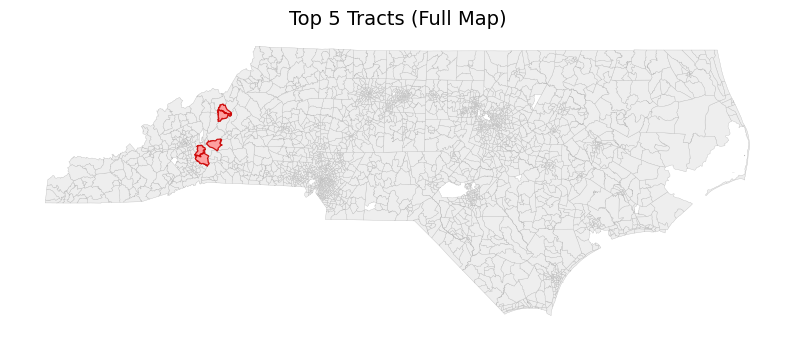

In [22]:
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 10))

# base layer
unique_gdf.plot(ax=ax1, color="#EEEEEE", edgecolor="#BBBBBB", linewidth=0.25)

# highlight top tracts
tops = unique_gdf[unique_gdf['is_top']]
if not tops.empty:
    tops.plot(
        ax=ax1,
        facecolor='#ff9999',
        edgecolor='#cc0000',
        linewidth=0.9,
        alpha=0.9,
        zorder=5
    )

ax1.set_axis_off()
ax1.set_title(f"Top {TOP_N} Tracts (Full Map)", fontsize=14)

output_full = output_png.replace(".png", "_full.png")
plt.savefig(output_full, bbox_inches='tight', pad_inches=0.05, dpi=300)
print("Saved full map to:", output_full)
plt.show()